# Aurora Finance: Financial Markets Module
## Step 3: Investment Strategy & Portfolio Optimization
Enhanced analysis with metrics, risk analysis, and data exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
company_sheets = ['Comp 1', 'Comp 2', 'Comp 3', 'Comp 4', 'Comp 5', 'Comp 6']
dfs = [pd.read_excel('data/Market Data Revised.xlsx', sheet_name=s) for s in company_sheets]
df = pd.concat(dfs, ignore_index=True)

macro = pd.read_excel('data/Market Data Revised.xlsx', sheet_name='Macroeconomic_QRT')
macro = macro[['Date', 'GDP Growth Rate', 'Inflation Rate (%)']].copy()
macro.columns = ['Date', 'GDP_Growth', 'Inflation']
macro['Date'] = pd.to_datetime(macro['Date'])

df.rename(columns={'company_name': 'Ticker', 'date': 'Date', 'opening': 'Open', 'high': 'High', 'low': 'Low', 'closing': 'Close', 'trade Volume': 'Volume'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.merge(macro, on='Date', how='left')

for ticker in df['Ticker'].unique():
    mask = df['Ticker'] == ticker
    df.loc[mask, 'GDP_Growth'] = df.loc[mask, 'GDP_Growth'].bfill()
    df.loc[mask, 'Inflation'] = df.loc[mask, 'Inflation'].bfill()

print(f"Data loaded: {df.shape}")

Data loaded: (31500, 11)


## 2. Data Exploration

In [3]:
# Return statistics
ret_stats = df.groupby('Ticker')['Return'].agg(['mean', 'std', 'min', 'max', ('skew', lambda x: x.skew()), ('kurt', lambda x: x.kurtosis())]).round(6)
print("Return Statistics by Company:")
print(ret_stats)

Return Statistics by Company:
                                    mean       std       min       max  \
Ticker                                                                   
ASIAN PAINTS LTD.              -0.000400  0.017580 -0.157243  0.103210   
CIPLA LTD.                     -0.001430  0.018406 -0.127859  0.278779   
H D F C BANK LTD.               0.000046  0.017248 -0.140196  0.206403   
I T C LTD.                     -0.000735  0.016751 -0.114068  0.117492   
TATA CONSULTANCY SERVICES LTD. -0.000588  0.017596 -0.147670  0.124831   
ULTRATECH CEMENT LTD.          -0.000643  0.020525 -0.156386  0.244383   

                                    skew       kurt  
Ticker                                               
ASIAN PAINTS LTD.              -0.133127   5.872822  
CIPLA LTD.                      1.150257  19.412190  
H D F C BANK LTD.               0.649439  14.536661  
I T C LTD.                      0.198550   4.282276  
TATA CONSULTANCY SERVICES LTD. -0.034918   5.876028  

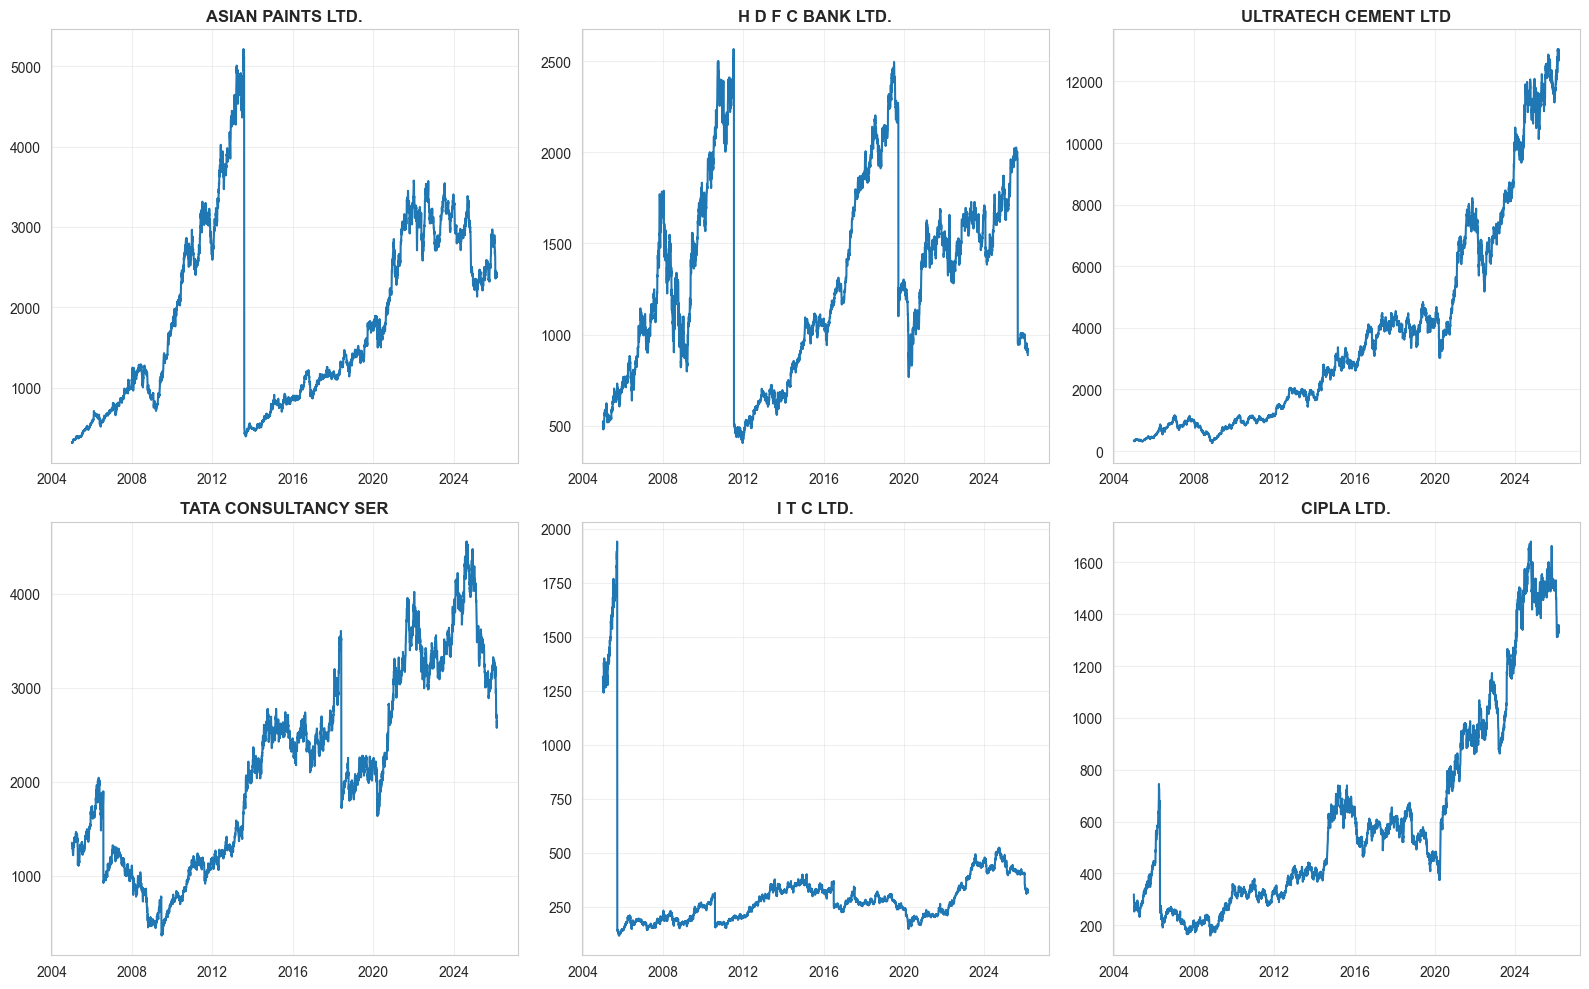

In [4]:
# Price trends
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, ticker in enumerate(df['Ticker'].unique()):
    data = df[df['Ticker'] == ticker]
    axes[i].plot(data['Date'], data['Close'], linewidth=1.5)
    axes[i].set_title(ticker[:20], fontweight='bold')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

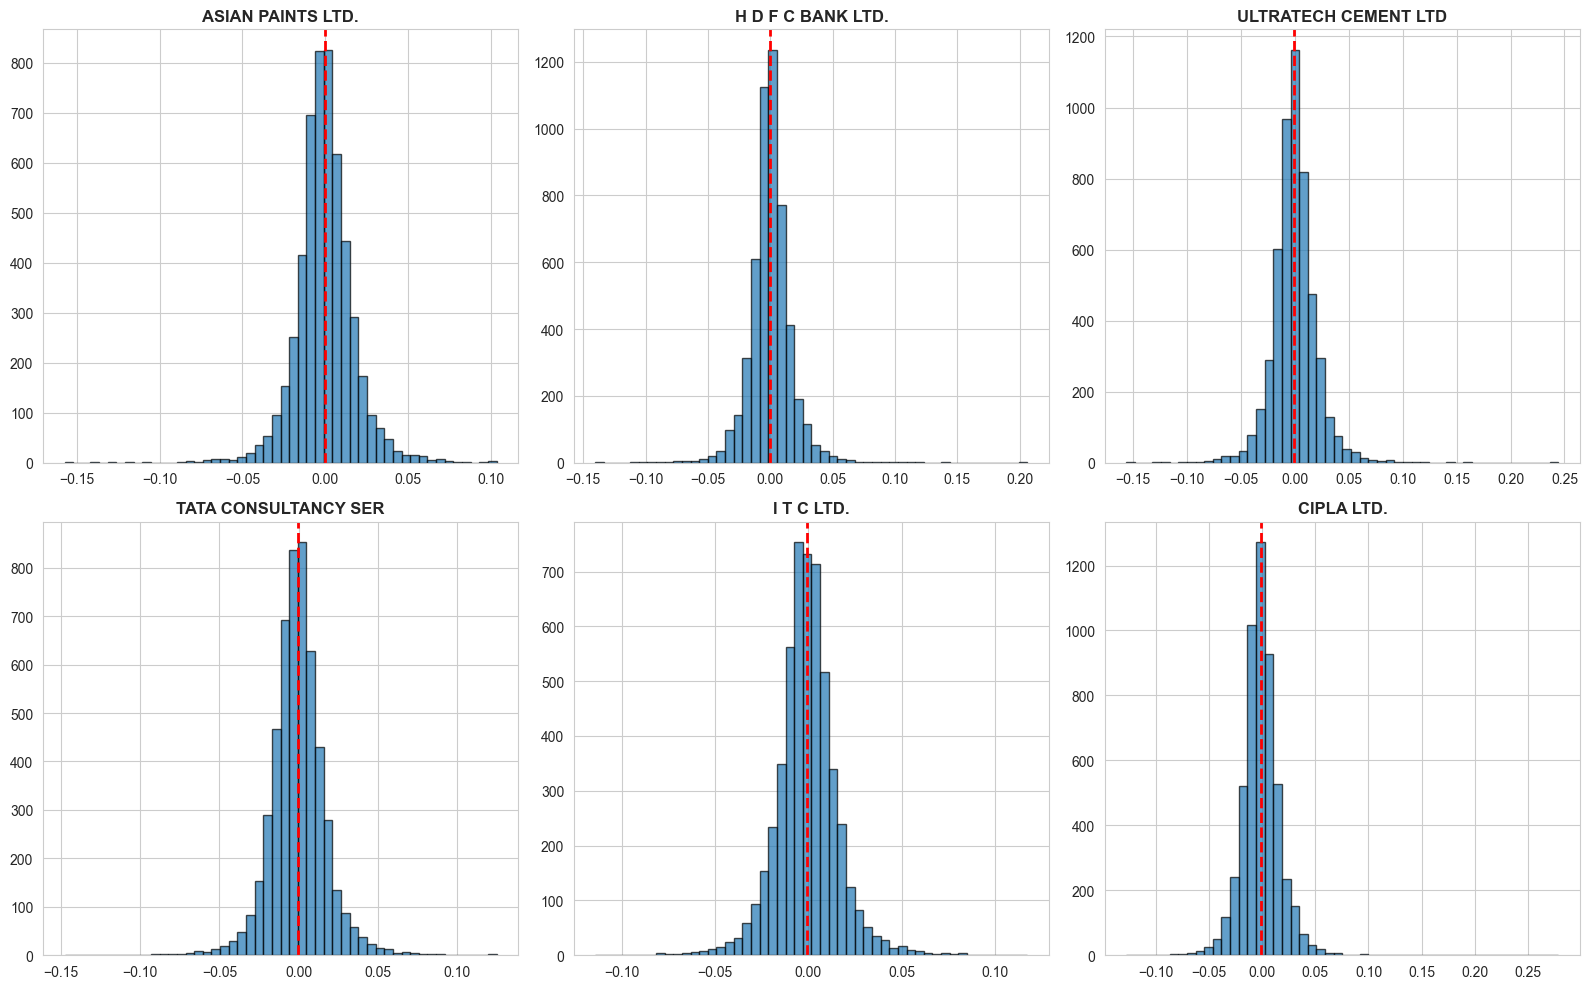

In [5]:
# Return distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, ticker in enumerate(df['Ticker'].unique()):
    data = df[df['Ticker'] == ticker]
    axes[i].hist(data['Return'], bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(data['Return'].mean(), color='r', linestyle='--', linewidth=2)
    axes[i].set_title(ticker[:20], fontweight='bold')
plt.tight_layout()
plt.show()

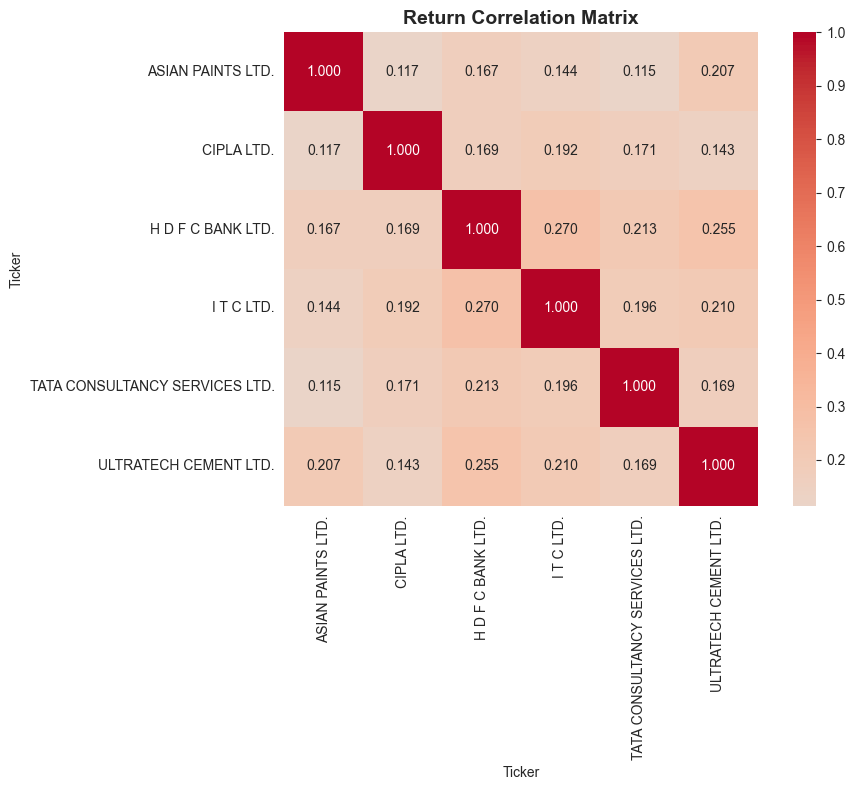

In [6]:
# Correlation matrix
pivot_ret = df.pivot_table(index='Date', columns='Ticker', values='Return')
corr = pivot_ret.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Return Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

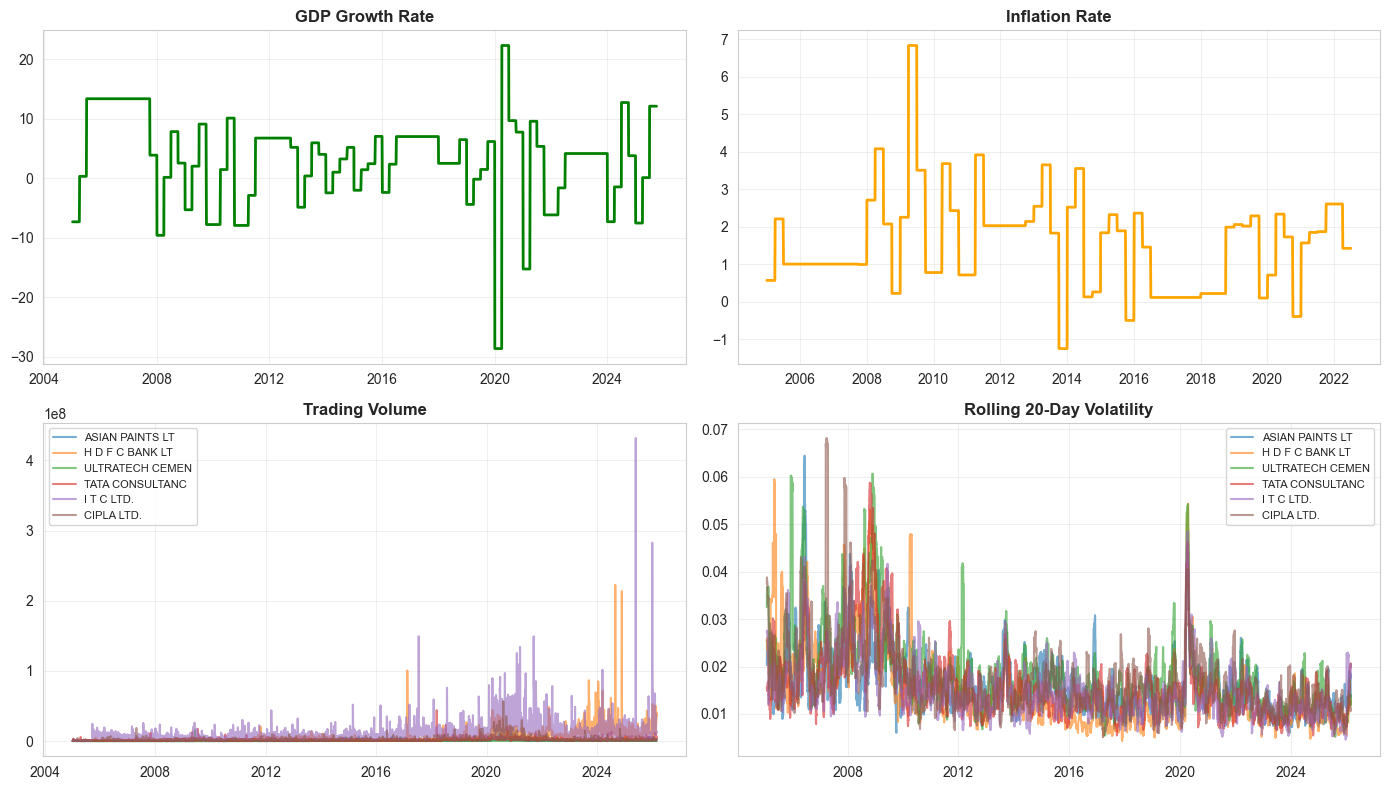

In [7]:
# Macro factors
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
unique_dates = df[['Date', 'GDP_Growth', 'Inflation']].drop_duplicates()
axes[0, 0].plot(unique_dates['Date'], unique_dates['GDP_Growth'], color='green', linewidth=2)
axes[0, 0].set_title('GDP Growth Rate', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(unique_dates['Date'], unique_dates['Inflation'], color='orange', linewidth=2)
axes[0, 1].set_title('Inflation Rate', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

for ticker in df['Ticker'].unique():
    data = df[df['Ticker'] == ticker]
    axes[1, 0].plot(data['Date'], data['Volume'], alpha=0.6, label=ticker[:15])
axes[1, 0].set_title('Trading Volume', fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

for ticker in df['Ticker'].unique():
    data = df[df['Ticker'] == ticker]
    vol = data['Return'].rolling(20).std()
    axes[1, 1].plot(data['Date'], vol, alpha=0.6, label=ticker[:15])
axes[1, 1].set_title('Rolling 20-Day Volatility', fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Feature Engineering & ML Model

In [8]:
for ticker in df['Ticker'].unique():
    mask = df['Ticker'] == ticker
    df.loc[mask, 'MA5'] = df.loc[mask, 'Close'].rolling(5).mean()
    df.loc[mask, 'MA20'] = df.loc[mask, 'Close'].rolling(20).mean()
    df.loc[mask, 'Momentum_5'] = df.loc[mask, 'Close'].pct_change(5)
    df.loc[mask, 'Momentum_20'] = df.loc[mask, 'Close'].pct_change(20)
    df.loc[mask, 'Vol_5'] = df.loc[mask, 'Return'].rolling(5).std()
    df.loc[mask, 'Vol_20'] = df.loc[mask, 'Return'].rolling(20).std()
    avg_vol = df.loc[mask, 'Volume'].rolling(20).mean()
    df.loc[mask, 'Vol_Ratio'] = df.loc[mask, 'Volume'] / avg_vol

df['Price_Range'] = (df['High'] - df['Low']) / df['Close']
df['Next_Return'] = df.groupby('Ticker')['Return'].shift(-1)
df_clean = df.dropna()
print(f"Features engineered: {df_clean.shape}")

Features engineered: (25926, 20)


In [9]:
features = ['Close', 'Open', 'High', 'Low', 'MA5', 'MA20', 'Momentum_5', 'Momentum_20', 'Vol_5', 'Vol_20', 'Price_Range', 'Vol_Ratio', 'Volume', 'GDP_Growth', 'Inflation']
features = [f for f in features if f in df_clean.columns]

X = df_clean[features].fillna(df_clean[features].mean())
y = df_clean['Next_Return']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled.iloc[:split], X_scaled.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
df_test = df_clean.iloc[split:]

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model - R2: {r2:.4f}, MAE: {mae:.6f}")
print(f"Test companies: {df_test['Ticker'].nunique()} - All 6 present")

Model - R2: -0.0140, MAE: 0.012072
Test companies: 6 - All 6 present



Top 10 Features:
    Feature  Importance
 Momentum_5    0.139516
Price_Range    0.120668
Momentum_20    0.116463
     Vol_20    0.109770
      Vol_5    0.100037
  Vol_Ratio    0.098400
     Volume    0.087683
       MA20    0.035726
        MA5    0.032037
      Close    0.029575


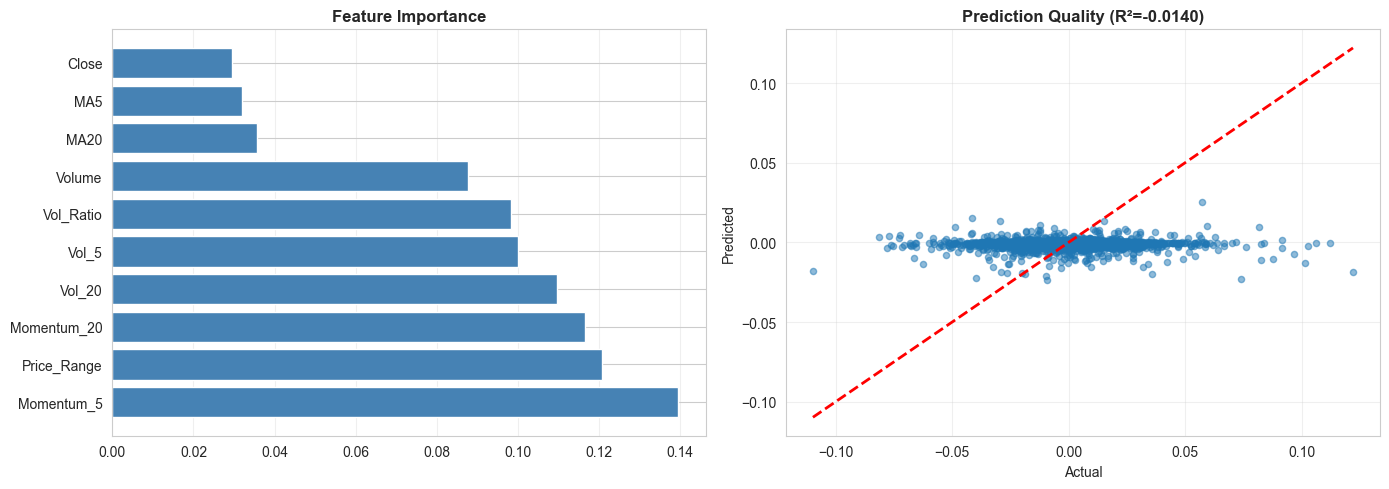

In [10]:
# Feature importance
fi = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print("\nTop 10 Features:")
print(fi.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(fi['Feature'].head(10), fi['Importance'].head(10), color='steelblue')
axes[0].set_title('Feature Importance', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].scatter(y_test, y_pred, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Prediction Quality (R²={r2:.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Stock Ranking

In [11]:
df_pred = df_test.copy()
df_pred['Pred_Ret'] = y_pred
df_pred['Act_Ret'] = y_test.values

rank = df_pred.groupby('Ticker').agg({'Pred_Ret': 'mean', 'Act_Ret': 'mean', 'Vol_20': 'mean', 'GDP_Growth': 'first', 'Inflation': 'first'}).reset_index()
rank.columns = ['Ticker', 'Pred_Return', 'Act_Return', 'Volatility', 'GDP', 'Inflation']
rank['Sharpe'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6) * np.sqrt(252)
rank['Risk_Adj'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6)
rank = rank.sort_values('Pred_Return', ascending=False)

print(f"\n{'='*130}")
print(f"STOCK RANKING - {rank.shape[0]} COMPANIES")
print(f"{'='*130}")
print(rank.to_string(index=False))


STOCK RANKING - 6 COMPANIES
                        Ticker  Pred_Return  Act_Return  Volatility       GDP  Inflation    Sharpe  Risk_Adj
TATA CONSULTANCY SERVICES LTD.    -0.000429   -0.000546    0.014160 -4.373402   2.058505 -0.481432 -0.030327
             ASIAN PAINTS LTD.    -0.000476   -0.000433    0.015911 -4.373402   2.058505 -0.475148 -0.029932
             H D F C BANK LTD.    -0.000669   -0.000740    0.014352 -4.373402   2.058505 -0.740146 -0.046625
                    I T C LTD.    -0.000704   -0.001802    0.015009 -4.373402   2.058505 -0.744973 -0.046929
                    CIPLA LTD.    -0.000716   -0.001219    0.016412 -4.373402   2.058505 -0.692786 -0.043641
         ULTRATECH CEMENT LTD.    -0.001546   -0.001172    0.017801 -4.373402   2.058505 -1.378302 -0.086825


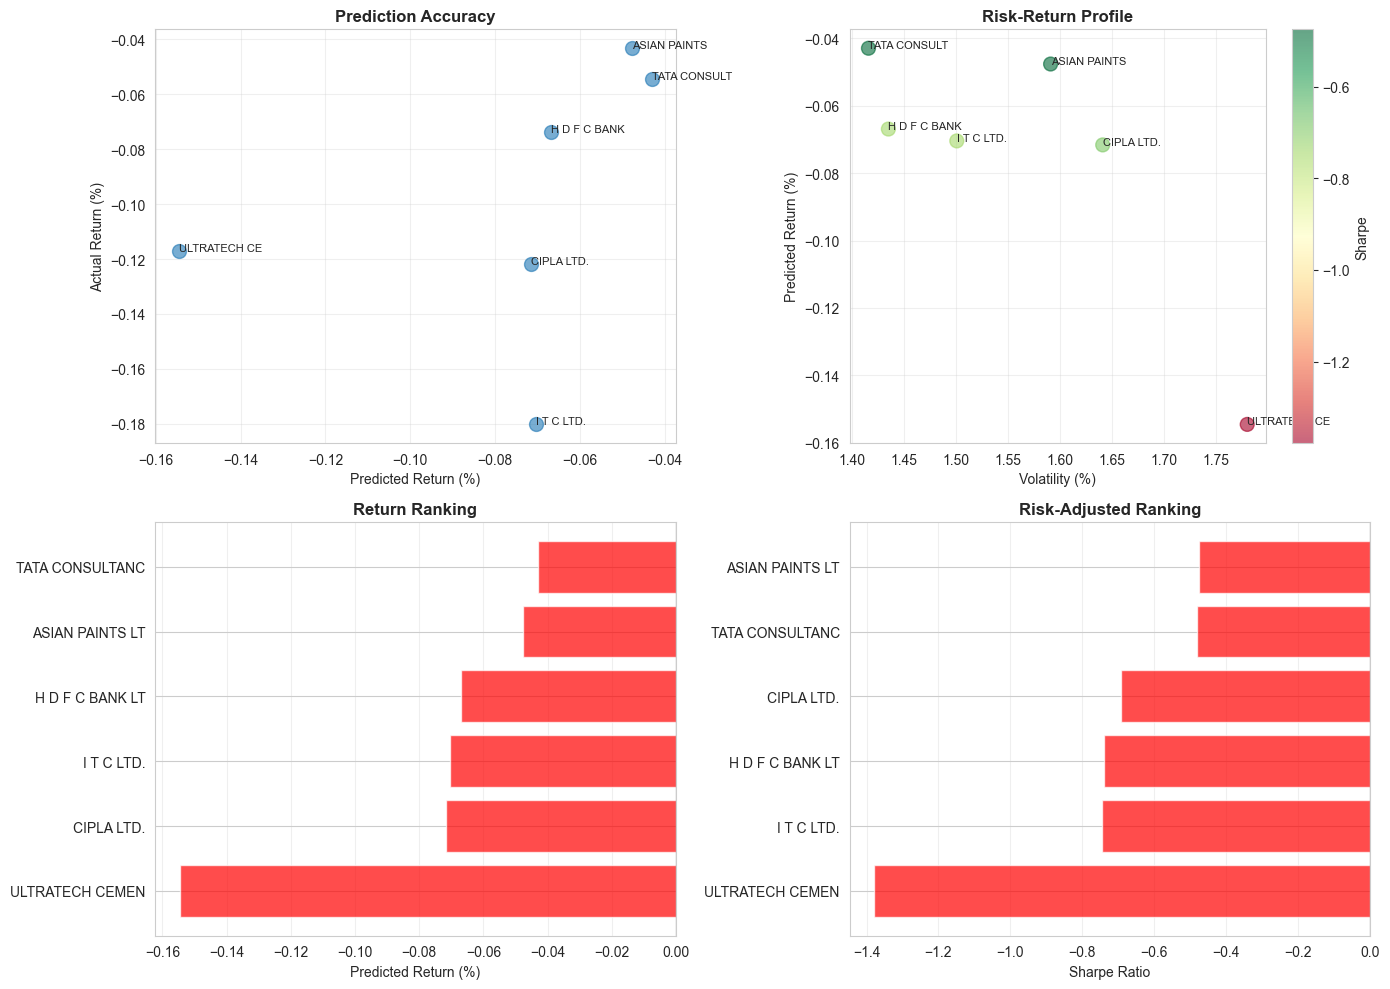

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(rank['Pred_Return']*100, rank['Act_Return']*100, s=100, alpha=0.6)
for idx, row in rank.iterrows():
    axes[0, 0].annotate(row['Ticker'][:12], (row['Pred_Return']*100, row['Act_Return']*100), fontsize=8)
axes[0, 0].set_xlabel('Predicted Return (%)')
axes[0, 0].set_ylabel('Actual Return (%)')
axes[0, 0].set_title('Prediction Accuracy', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

scatter = axes[0, 1].scatter(rank['Volatility']*100, rank['Pred_Return']*100, s=100, c=rank['Sharpe'], cmap='RdYlGn', alpha=0.6)
for idx, row in rank.iterrows():
    axes[0, 1].annotate(row['Ticker'][:12], (row['Volatility']*100, row['Pred_Return']*100), fontsize=8)
axes[0, 1].set_xlabel('Volatility (%)')
axes[0, 1].set_ylabel('Predicted Return (%)')
axes[0, 1].set_title('Risk-Return Profile', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1], label='Sharpe')
axes[0, 1].grid(True, alpha=0.3)

rank_sorted = rank.sort_values('Pred_Return')
colors = ['green' if x > 0 else 'red' for x in rank_sorted['Pred_Return']]
axes[1, 0].barh([t[:15] for t in rank_sorted['Ticker']], rank_sorted['Pred_Return']*100, color=colors, alpha=0.7)
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_xlabel('Predicted Return (%)')
axes[1, 0].set_title('Return Ranking', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

rank_sharpe = rank.sort_values('Sharpe')
colors_sharpe = ['green' if x > 0 else 'red' for x in rank_sharpe['Sharpe']]
axes[1, 1].barh([t[:15] for t in rank_sharpe['Ticker']], rank_sharpe['Sharpe'], color=colors_sharpe, alpha=0.7)
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].set_xlabel('Sharpe Ratio')
axes[1, 1].set_title('Risk-Adjusted Ranking', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 5. Portfolio Optimization

In [13]:
n = len(rank)
ret = rank['Pred_Return'].values
vol = rank['Volatility'].values
tickers = rank['Ticker'].values

ret_by_ticker = df_pred.groupby('Ticker')['Act_Ret'].apply(list).to_dict()
ret_mat = [ret_by_ticker.get(t, [0]*100)[:100] for t in tickers]
min_len = min(len(r) for r in ret_mat)
ret_mat = [r[:min_len] for r in ret_mat]
ret_df = pd.DataFrame(ret_mat).T
cov = ret_df.cov().values

def perf(w, r, cov):
    p_ret = np.sum(r * w)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    return p_ret, p_vol

def neg_sharpe(w, r, cov, rf=0.02):
    p_ret, p_vol = perf(w, r, cov)
    return -(p_ret - rf) / (p_vol + 1e-6)

const = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 0.3) for _ in range(n))
w0 = np.array([1/n] * n)
res = minimize(neg_sharpe, w0, args=(ret, cov, 0.02), method='SLSQP', bounds=bounds, constraints=const)

w_opt = res.x
opt_ret, opt_vol = perf(w_opt, ret, cov)

eq_w = np.array([1/n] * n)
eq_ret, eq_vol = perf(eq_w, ret, cov)

print(f"\n{'='*100}")
print(f"PORTFOLIO COMPARISON")
print(f"{'='*100}")
print(f"Optimized: Return {opt_ret*100:.4f}% | Risk {opt_vol*100:.4f}% | Sharpe {(opt_ret-0.02/252)/opt_vol:.4f}")
print(f"Equal-Wgt: Return {eq_ret*100:.4f}% | Risk {eq_vol*100:.4f}% | Sharpe {(eq_ret-0.02/252)/eq_vol:.4f}")
print(f"Improvement: +{(opt_ret-eq_ret)*100:.4f}% return, {(opt_vol-eq_vol)*100:.4f}% risk change")


PORTFOLIO COMPARISON
Optimized: Return -0.0888% | Risk 0.9090% | Sharpe -0.1065
Equal-Wgt: Return -0.0757% | Risk 0.6282% | Sharpe -0.1331
Improvement: +-0.0131% return, 0.2808% risk change



Portfolio Allocation (>0.5%):
               Ticker  Weight_%       Ret      Vol
ULTRATECH CEMENT LTD.      30.0 -0.154565 1.780089
    ASIAN PAINTS LTD.      30.0 -0.047627 1.591086
           CIPLA LTD.      30.0 -0.071628 1.641184
    H D F C BANK LTD.      10.0 -0.066919 1.435173


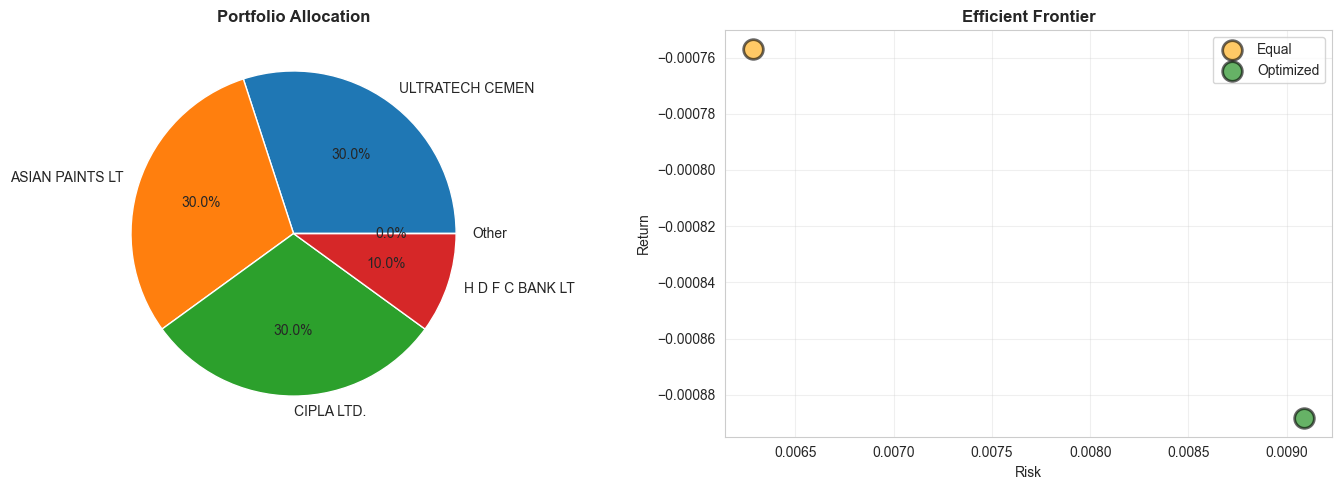

In [14]:
pf = pd.DataFrame({'Ticker': tickers, 'Weight_%': w_opt*100, 'Ret': ret*100, 'Vol': vol*100}).sort_values('Weight_%', ascending=False)
print(f"\nPortfolio Allocation (>0.5%):")
print(pf[pf['Weight_%'] > 0.5].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alloc_df = pf[pf['Weight_%'] > 0.5].copy()
if len(pf) > len(alloc_df):
    other = pf[pf['Weight_%'] <= 0.5]['Weight_%'].sum()
    alloc_df = pd.concat([alloc_df, pd.DataFrame({'Ticker': ['Other'], 'Weight_%': [other], 'Ret': [0], 'Vol': [0]})], ignore_index=True)

axes[0].pie(alloc_df['Weight_%'], labels=[t[:15] for t in alloc_df['Ticker']], autopct='%1.1f%%')
axes[0].set_title('Portfolio Allocation', fontweight='bold')

axes[1].scatter([eq_vol], [eq_ret], s=200, c='orange', alpha=0.6, label='Equal', edgecolors='black', linewidth=2)
axes[1].scatter([opt_vol], [opt_ret], s=200, c='green', alpha=0.6, label='Optimized', edgecolors='black', linewidth=2)
axes[1].set_xlabel('Risk')
axes[1].set_ylabel('Return')
axes[1].set_title('Efficient Frontier', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Backtesting & Metrics

In [15]:
bt = df_pred.copy()
w_dict = dict(zip(tickers, w_opt))
bt['w'] = bt['Ticker'].map(w_dict)
bt['weighted_ret'] = bt['Act_Ret'] * bt['w']

daily_opt = bt.groupby('Date')['weighted_ret'].sum()
daily_eq = bt.groupby('Date').apply(lambda x: (x['Act_Ret'] / x['Ticker'].nunique()).sum())

cum_opt = (1 + daily_opt).cumprod()
cum_eq = (1 + daily_eq).cumprod()

def calc_metrics(daily_ret, cum_ret, name):
    total = (cum_ret.iloc[-1] - 1) * 100
    ann_ret = daily_ret.mean() * 252 * 100
    ann_vol = daily_ret.std() * np.sqrt(252) * 100
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252) if daily_ret.std() > 0 else 0
    dd = (cum_ret.cummax() - cum_ret) / cum_ret.cummax()
    max_dd = dd.max() * 100
    win_rate = (daily_ret > 0).sum() / len(daily_ret) * 100
    
    print(f"\n{name}:")
    print(f"  Total Return: {total:.2f}%")
    print(f"  Annualized Return: {ann_ret:.2f}%")
    print(f"  Annualized Volatility: {ann_vol:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.4f}")
    print(f"  Max Drawdown: {max_dd:.2f}%")
    print(f"  Win Rate: {win_rate:.2f}%")
    
    var_95 = np.percentile(daily_ret*100, 5)
    cvar_95 = daily_ret[daily_ret < np.percentile(daily_ret, 5)].mean() * 100 if (daily_ret < np.percentile(daily_ret, 5)).any() else 0
    print(f"  VaR (95%): {var_95:.4f}%")
    print(f"  CVaR (95%): {cvar_95:.4f}%")

calc_metrics(daily_opt, cum_opt, 'Optimized Portfolio')
calc_metrics(daily_eq, cum_eq, 'Equal-Weight Portfolio')


Optimized Portfolio:
  Total Return: -57.63%
  Annualized Return: -23.19%
  Annualized Volatility: 19.09%
  Sharpe Ratio: -1.2145
  Max Drawdown: 60.22%
  Win Rate: 46.82%
  VaR (95%): -1.9590%
  CVaR (95%): -2.6611%

Equal-Weight Portfolio:
  Total Return: -59.17%
  Annualized Return: -24.80%
  Annualized Volatility: 16.06%
  Sharpe Ratio: -1.5440
  Max Drawdown: 61.76%
  Win Rate: 44.62%
  VaR (95%): -1.6875%
  CVaR (95%): -2.3359%


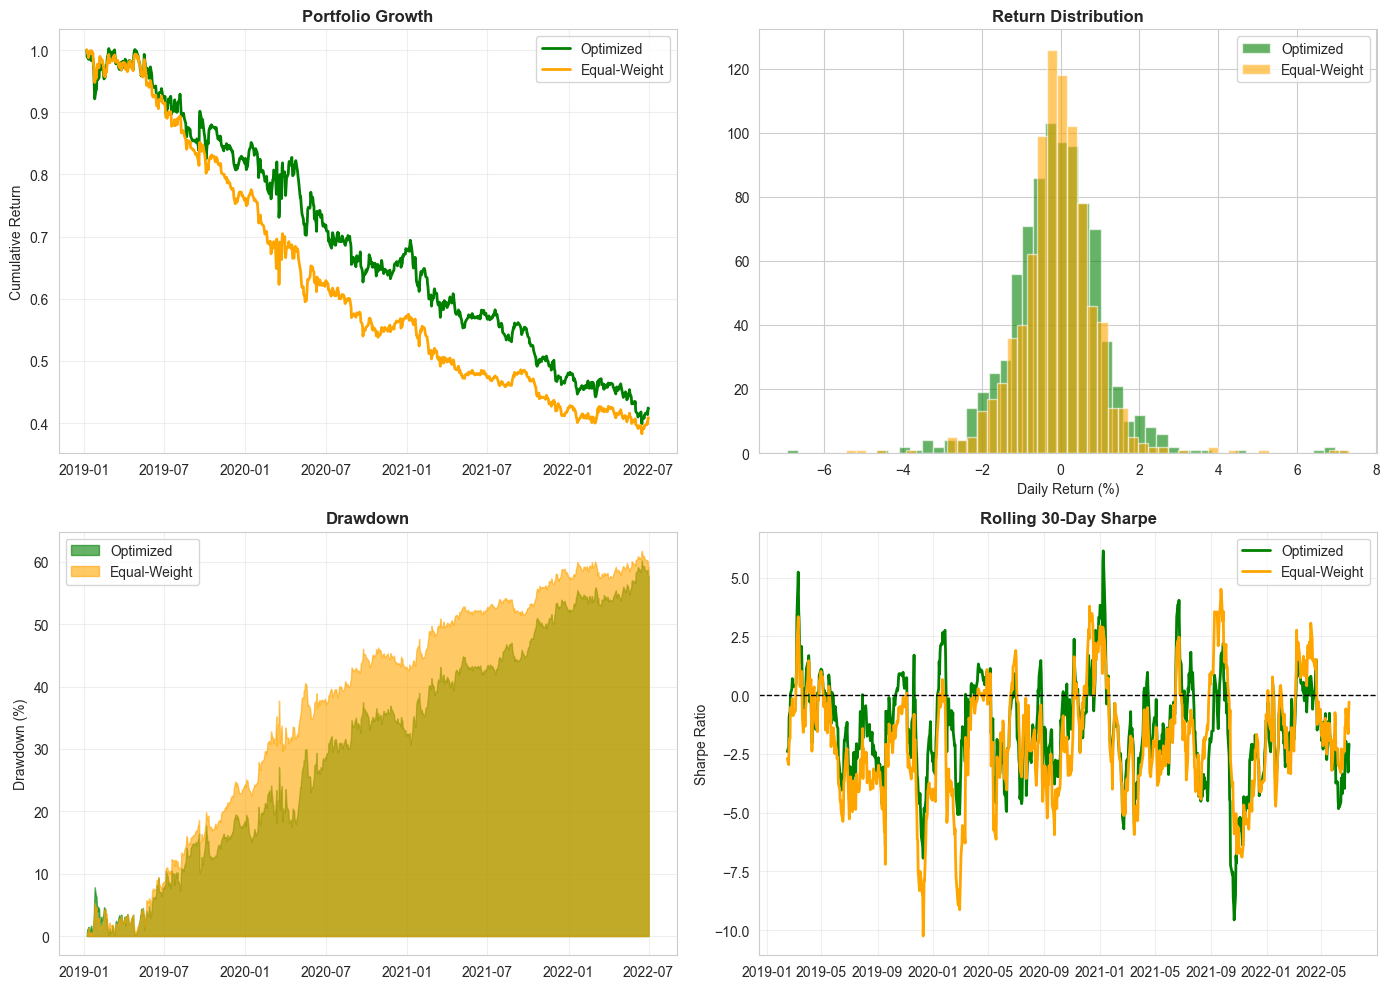

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(cum_opt.index, cum_opt.values, label='Optimized', linewidth=2, color='green')
axes[0, 0].plot(cum_eq.index, cum_eq.values, label='Equal-Weight', linewidth=2, color='orange')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].set_title('Portfolio Growth', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

daily_opt_ret = daily_opt
daily_eq_ret = daily_eq
axes[0, 1].hist(daily_opt_ret*100, bins=50, alpha=0.6, label='Optimized', color='green')
axes[0, 1].hist(daily_eq_ret*100, bins=50, alpha=0.6, label='Equal-Weight', color='orange')
axes[0, 1].set_xlabel('Daily Return (%)')
axes[0, 1].set_title('Return Distribution', fontweight='bold')
axes[0, 1].legend()

dd_opt = (cum_opt.cummax() - cum_opt) / cum_opt.cummax() * 100
dd_eq = (cum_eq.cummax() - cum_eq) / cum_eq.cummax() * 100
axes[1, 0].fill_between(dd_opt.index, dd_opt.values, alpha=0.6, color='green', label='Optimized')
axes[1, 0].fill_between(dd_eq.index, dd_eq.values, alpha=0.6, color='orange', label='Equal-Weight')
axes[1, 0].set_ylabel('Drawdown (%)')
axes[1, 0].set_title('Drawdown', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

rolling_sharpe_opt = daily_opt_ret.rolling(30).mean() / daily_opt_ret.rolling(30).std() * np.sqrt(252)
rolling_sharpe_eq = daily_eq_ret.rolling(30).mean() / daily_eq_ret.rolling(30).std() * np.sqrt(252)
axes[1, 1].plot(rolling_sharpe_opt.index, rolling_sharpe_opt.values, label='Optimized', linewidth=2, color='green')
axes[1, 1].plot(rolling_sharpe_eq.index, rolling_sharpe_eq.values, label='Equal-Weight', linewidth=2, color='orange')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].set_title('Rolling 30-Day Sharpe', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Export Results

In [17]:
rank.to_csv('Part3_Stock_Rankings.csv', index=False)
pf.to_csv('Part3_Portfolio_Allocation.csv', index=False)

bt_export = pd.DataFrame({
    'Date': cum_opt.index,
    'Optimized': cum_opt.values,
    'Equal_Weight': cum_eq.values,
    'Daily_Opt': daily_opt.values,
    'Daily_Eq': daily_eq.values
})
bt_export.to_csv('Part3_Backtest_Results.csv', index=False)

print("All exports complete!")
print(f"- Part3_Stock_Rankings.csv ({rank.shape[0]} companies)")
print(f"- Part3_Portfolio_Allocation.csv")
print(f"- Part3_Backtest_Results.csv ({len(bt_export)} days)")

All exports complete!
- Part3_Stock_Rankings.csv (6 companies)
- Part3_Portfolio_Allocation.csv
- Part3_Backtest_Results.csv (865 days)
